In [1]:
import os, warnings, copy
warnings.filterwarnings("ignore")

import polars as pl
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib

import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader
from sklearn.metrics import mean_absolute_error, root_mean_squared_error, r2_score
from sklearn.preprocessing import MinMaxScaler

plt.style.use("seaborn-v0_8-darkgrid")

DATA_DIR   = "../data"
MODEL_DIR  = "../outputs/models"
REPORT_DIR = "../outputs/reports"
os.makedirs(MODEL_DIR,  exist_ok=True)
os.makedirs(REPORT_DIR, exist_ok=True)

DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")

print("=" * 60)
print("  NOTEBOOK 05 — Transformer Model Comparison")
print("  PatchTST | Vanilla Transformer | TiDE | Informer")
print("=" * 60)
print(f"  Device  : {DEVICE}")
if torch.cuda.is_available():
    print(f"  GPU     : {torch.cuda.get_device_name(0)}")
    print(f"  VRAM    : {torch.cuda.get_device_properties(0).total_memory/1e9:.1f} GB")
print(f"  PyTorch : {torch.__version__}")

  NOTEBOOK 05 — Transformer Model Comparison
  PatchTST | Vanilla Transformer | TiDE | Informer
  Device  : cuda
  GPU     : NVIDIA GeForce RTX 3050 A Laptop GPU
  VRAM    : 4.3 GB
  PyTorch : 2.5.1+cu121


In [2]:
SEQ_LEN        = 24     # 24 x 5min = 2hr lookback
FORECAST_STEPS = 3      # 3 x 5min = 15min ahead
BATCH_SIZE     = 64     # Smaller batch — safe for Transformer VRAM
EPOCHS         = 50
LR             = 3e-4   # lower LR -> more stable convergence
EARLY_STOP     = 10
PRIMARY_TARGET = "target_gpu_pct"

print(f"  SEQ_LEN        : {SEQ_LEN} steps  ({SEQ_LEN*5} min lookback)")
print(f"  FORECAST_STEPS : {FORECAST_STEPS} steps  ({FORECAST_STEPS*5} min ahead)")
print(f"  BATCH_SIZE     : {BATCH_SIZE}")
print(f"  EPOCHS         : {EPOCHS}")
print(f"  LR             : {LR}")
print(f"  EARLY_STOP     : {EARLY_STOP}")
print(f"  TARGET         : {PRIMARY_TARGET}")

  SEQ_LEN        : 24 steps  (120 min lookback)
  FORECAST_STEPS : 3 steps  (15 min ahead)
  BATCH_SIZE     : 64
  EPOCHS         : 50
  LR             : 0.0003
  EARLY_STOP     : 10
  TARGET         : target_gpu_pct


In [3]:
df = pl.read_parquet(f"{DATA_DIR}/interim/metrics_featured.parquet")

# Use ONLY raw sensor columns as features — no lag/rolling leakage into sequences
# The sequence window itself provides temporal context to the model
FEAT_COLS = [
    "machine_gpu", "machine_cpu_usr", "machine_cpu_kernel",
    "machine_cpu_iowait", "machine_load_1", "machine_net_receive",
    "cap_gpu", "cap_cpu", "cap_mem",
    "hour_of_day", "day_of_week"
]

print(f"Loaded {df.shape[0]:,} rows x {df.shape[1]} cols")
print(f"   Features used : {len(FEAT_COLS)}")
print(f"   Target        : {PRIMARY_TARGET}")
print(f"\n   Feature list:")
for i, c in enumerate(FEAT_COLS):
    mn  = df[c].mean()
    mx  = df[c].max()
    print(f"   {i+1:02d}. {c:<28}  mean={mn:7.2f}  max={mx:7.2f}")

Loaded 83,244 rows x 40 cols
   Features used : 11
   Target        : target_gpu_pct

   Feature list:
   01. machine_gpu                   mean=  50.55  max= 645.28
   02. machine_cpu_usr               mean=  15.74  max=  94.96
   03. machine_cpu_kernel            mean=   3.13  max=  71.37
   04. machine_cpu_iowait            mean=   0.00  max=   0.34
   05. machine_load_1                mean=  23.88  max=1029.54
   06. machine_net_receive           mean=160101028.23  max=3128768512.00
   07. cap_gpu                       mean=   2.04  max=   8.00
   08. cap_cpu                       mean=  96.00  max=  96.00
   09. cap_mem                       mean= 511.05  max= 512.00
   10. hour_of_day                   mean=  10.46  max=  23.00
   11. day_of_week                   mean=   3.87  max=   7.00


In [4]:
g_min = df["timestamp"].min()
g_max = df["timestamp"].max()
dur   = g_max - g_min

train_cut = g_min + dur * 0.70
val_cut   = g_min + dur * 0.85

train_pl = df.filter(pl.col("timestamp") <= train_cut)
val_pl   = df.filter((pl.col("timestamp") > train_cut) & (pl.col("timestamp") <= val_cut))
test_pl  = df.filter(pl.col("timestamp") > val_cut)

print(f"Chronological split (no shuffle — time series rule)")
print(f"   Train : {train_pl.shape[0]:,} rows  | {train_pl['timestamp'].min()} -> {train_pl['timestamp'].max()}")
print(f"   Val   : {val_pl.shape[0]:,}  rows  | {val_pl['timestamp'].min()} -> {val_pl['timestamp'].max()}")
print(f"   Test  : {test_pl.shape[0]:,}  rows  | {test_pl['timestamp'].min()} -> {test_pl['timestamp'].max()}")

Chronological split (no shuffle — time series rule)
   Train : 56,036 rows  | 1970-01-28 07:55:00 -> 1970-03-02 11:00:00
   Val   : 13,491  rows  | 1970-03-02 11:05:00 -> 1970-03-09 13:20:00
   Test  : 13,717  rows  | 1970-03-09 13:30:00 -> 1970-03-16 15:50:00


In [5]:
# MinMaxScaler keeps values in [0,1] — better for attention activations
scaler_X = MinMaxScaler()
scaler_y = MinMaxScaler()

X_tr = train_pl[FEAT_COLS].to_numpy().astype(np.float32)
X_vl = val_pl[FEAT_COLS].to_numpy().astype(np.float32)
X_te = test_pl[FEAT_COLS].to_numpy().astype(np.float32)

y_tr = train_pl[PRIMARY_TARGET].to_numpy().astype(np.float32).reshape(-1, 1)
y_vl = val_pl[PRIMARY_TARGET].to_numpy().astype(np.float32).reshape(-1, 1)
y_te = test_pl[PRIMARY_TARGET].to_numpy().astype(np.float32).reshape(-1, 1)

X_tr_s = scaler_X.fit_transform(X_tr)
X_vl_s = scaler_X.transform(X_vl)
X_te_s = scaler_X.transform(X_te)

y_tr_s = scaler_y.fit_transform(y_tr).flatten()
y_vl_s = scaler_y.transform(y_vl).flatten()
y_te_s = scaler_y.transform(y_te).flatten()

joblib.dump(scaler_X, f"{MODEL_DIR}/transformer_scaler_X.pkl")
joblib.dump(scaler_y, f"{MODEL_DIR}/transformer_scaler_y.pkl")

print(f"Scaled with MinMaxScaler (fit on train only)")
print(f"   X_train : {X_tr_s.shape}  range [{X_tr_s.min():.2f}, {X_tr_s.max():.2f}]")
print(f"   y_train : {y_tr_s.shape}  range [{y_tr_s.min():.4f}, {y_tr_s.max():.4f}]")
print(f"   y_val   : {y_vl_s.shape}  range [{y_vl_s.min():.4f}, {y_vl_s.max():.4f}]")
print(f"   y_test  : {y_te_s.shape}  range [{y_te_s.min():.4f}, {y_te_s.max():.4f}]")

Scaled with MinMaxScaler (fit on train only)
   X_train : (56036, 11)  range [0.00, 1.00]
   y_train : (56036,)  range [0.0000, 1.0000]
   y_val   : (13491,)  range [0.0000, 1.0000]
   y_test  : (13717,)  range [0.0003, 1.0000]


In [6]:
def make_sequences(X, y_flat, machine_ids, seq_len, forecast_steps):
    """
    Sliding window sequences strictly within each machine.
    Never crosses machine boundaries.
    Returns:
        X_seq : (N, seq_len, n_features)
        y_seq : (N,)  target value at t + forecast_steps
    """
    Xs, ys = [], []
    for machine in np.unique(machine_ids):
        idx  = np.where(machine_ids == machine)[0]
        X_m  = X[idx]
        y_m  = y_flat[idx]
        n    = len(X_m)
        for i in range(n - seq_len - forecast_steps + 1):
            Xs.append(X_m[i : i + seq_len])
            ys.append(y_m[i + seq_len + forecast_steps - 1])
    return np.array(Xs, dtype=np.float32), np.array(ys, dtype=np.float32)


train_mids = train_pl["machine"].to_numpy()
val_mids   = val_pl["machine"].to_numpy()
test_mids  = test_pl["machine"].to_numpy()

print("Building sequences per machine (no cross-machine leakage)...")

X_seq_tr, y_seq_tr = make_sequences(X_tr_s, y_tr_s, train_mids, SEQ_LEN, FORECAST_STEPS)
X_seq_vl, y_seq_vl = make_sequences(X_vl_s, y_vl_s, val_mids,   SEQ_LEN, FORECAST_STEPS)
X_seq_te, y_seq_te = make_sequences(X_te_s, y_te_s, test_mids,  SEQ_LEN, FORECAST_STEPS)

N_FEAT = X_seq_tr.shape[2]

print(f"\nSequences ready")
print(f"{'Split':<8} {'Shape':>25} {'y min':>8} {'y max':>8} {'y mean':>8}")
print(f"{'__'*8} {'__'*12} {'__'*8} {'__'*8} {'__'*8}")
for nm, Xs, ys in [("Train", X_seq_tr, y_seq_tr),
                    ("Val",   X_seq_vl, y_seq_vl),
                    ("Test",  X_seq_te, y_seq_te)]:
    print(f"{nm:<8} {str(Xs.shape):>25} {ys.min():>8.4f} {ys.max():>8.4f} {ys.mean():>8.4f}")

print(f"\n  n_features per timestep : {N_FEAT}")
print(f"  y is MinMax scaled      : expect range [0.0, 1.0]")

Building sequences per machine (no cross-machine leakage)...

Sequences ready
Split                        Shape    y min    y max   y mean
________________ ________________________ ________________ ________________ ________________
Train              (53436, 24, 11)   0.0000   1.0000   0.4684
Val                (11023, 24, 11)   0.0073   1.0000   0.5356
Test               (11120, 24, 11)   0.0036   1.0000   0.5670

  n_features per timestep : 11
  y is MinMax scaled      : expect range [0.0, 1.0]


In [7]:
class TSDataset(Dataset):
    def __init__(self, X, y):
        self.X = torch.tensor(X, dtype=torch.float32)
        self.y = torch.tensor(y, dtype=torch.float32)
    def __len__(self):         return len(self.X)
    def __getitem__(self, i):  return self.X[i], self.y[i]


train_loader = DataLoader(TSDataset(X_seq_tr, y_seq_tr), batch_size=BATCH_SIZE, shuffle=True,  drop_last=True)
val_loader   = DataLoader(TSDataset(X_seq_vl, y_seq_vl), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)
test_loader  = DataLoader(TSDataset(X_seq_te, y_seq_te), batch_size=BATCH_SIZE, shuffle=False, drop_last=False)

print(f"DataLoaders ready")
print(f"   Train : {len(train_loader):>4} batches  ({len(X_seq_tr):,} sequences)")
print(f"   Val   : {len(val_loader):>4} batches  ({len(X_seq_vl):,} sequences)")
print(f"   Test  : {len(test_loader):>4} batches  ({len(X_seq_te):,} sequences)")
print(f"   Batch shape : [B={BATCH_SIZE}, T={SEQ_LEN}, F={N_FEAT}]")

DataLoaders ready
   Train :  834 batches  (53,436 sequences)
   Val   :  173 batches  (11,023 sequences)
   Test  :  174 batches  (11,120 sequences)
   Batch shape : [B=64, T=24, F=11]


In [8]:
def train_one_model(model, name, train_loader, val_loader, epochs, lr, early_stop):
    optimizer = torch.optim.Adam(model.parameters(), lr=lr, weight_decay=1e-4)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
                    optimizer, mode="min", patience=5, factor=0.5,
                    min_lr=1e-6, verbose=False)
    criterion    = nn.HuberLoss(delta=1.0)
    best_val     = float("inf")
    best_state   = None
    train_losses = []
    val_losses   = []
    pat_counter  = 0

    print(f"\n{'='*58}")
    print(f"  =>  {name}")
    print(f"  Params : {sum(p.numel() for p in model.parameters() if p.requires_grad):,}")
    print(f"  LR     : {lr}   |   Early stop: {early_stop} epochs")
    print(f"{'='*58}")
    print(f"  {'Epoch':>5}  {'Train':>10}  {'Val':>10}  {'LR':>10}  Status")
    print(f"  {'_'*5}  {'_'*10}  {'_'*10}  {'_'*10}  {'_'*12}")

    for epoch in range(1, epochs + 1):
        # Train phase
        model.train()
        t_loss = 0.0
        for Xb, yb in train_loader:
            Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
            optimizer.zero_grad()
            pred = model(Xb).squeeze(-1)
            loss = criterion(pred, yb)
            loss.backward()
            nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)
            optimizer.step()
            t_loss += loss.item()

        # Val phase
        model.eval()
        v_loss = 0.0
        with torch.no_grad():
            for Xb, yb in val_loader:
                Xb, yb = Xb.to(DEVICE), yb.to(DEVICE)
                pred    = model(Xb).squeeze(-1)
                v_loss += criterion(pred, yb).item()

        t_avg  = t_loss / len(train_loader)
        v_avg  = v_loss / len(val_loader)
        cur_lr = optimizer.param_groups[0]["lr"]
        train_losses.append(t_avg)
        val_losses.append(v_avg)
        scheduler.step(v_avg)

        if v_avg < best_val:
            best_val    = v_avg
            best_state  = copy.deepcopy(model.state_dict())
            pat_counter = 0
            status      = "best"
        else:
            pat_counter += 1
            status       = f"wait {pat_counter}/{early_stop}"

        print(f"  {epoch:>5}  {t_avg:>10.6f}  {v_avg:>10.6f}  {cur_lr:>10.6f}  {status}")

        if pat_counter >= early_stop:
            print(f"\n  Early stop at epoch {epoch}")
            break

    model.load_state_dict(best_state)
    print(f"\n  Best val loss : {best_val:.6f}")
    return model, train_losses, val_losses


def evaluate_model(model, test_loader, scaler_y):
    """Run inference -> inverse scale -> compute metrics"""
    model.eval()
    preds_s, acts_s = [], []
    with torch.no_grad():
        for Xb, yb in test_loader:
            p = model(Xb.to(DEVICE)).squeeze(-1).cpu().numpy()
            preds_s.append(p)
            acts_s.append(yb.numpy())
    preds_s = np.concatenate(preds_s).reshape(-1, 1)
    acts_s  = np.concatenate(acts_s).reshape(-1, 1)
    preds   = scaler_y.inverse_transform(preds_s).flatten()
    acts    = scaler_y.inverse_transform(acts_s).flatten()
    mae     = mean_absolute_error(acts, preds)
    rmse    = root_mean_squared_error(acts, preds)
    r2      = r2_score(acts, preds)
    mape    = np.mean(np.abs((acts - preds) / (np.abs(acts) + 1e-8))) * 100
    return preds, acts, {"MAE": mae, "RMSE": rmse, "R2": r2, "MAPE": mape}


print("train_one_model() and evaluate_model() defined")
print("   Ready to train each model individually below")

train_one_model() and evaluate_model() defined
   Ready to train each model individually below


In [9]:
# MODEL 1: PatchTST
# Patch-based Time Series Transformer (Nie et al., 2023)
# Segments the time series into patches -> each patch becomes one token
# Drastically reduces sequence length seen by attention mechanism
# Benefits: fewer tokens -> lower O(n^2) cost, better local-pattern capture

class PatchTSTModel(nn.Module):
    def __init__(self, n_feat, seq_len, patch_len=4, stride=4,
                 d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.patch_len = patch_len
        self.stride    = stride
        self.pad_len   = max(0, patch_len - stride)
        padded_len     = seq_len + self.pad_len
        self.n_patches = (padded_len - patch_len) // stride + 1

        self.patch_embed = nn.Linear(patch_len * n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(1, self.n_patches, d_model))

        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.Flatten(start_dim=1),
            nn.Linear(self.n_patches * d_model, 64), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(64, 1)
        )

    def forward(self, x):   # x: [B, T, F]
        B = x.size(0)
        if self.pad_len > 0:
            pad = torch.zeros(B, self.pad_len, x.size(2), device=x.device)
            x   = torch.cat([pad, x], dim=1)
        patches = x.unfold(1, self.patch_len, self.stride)
        patches = patches.contiguous().view(B, self.n_patches, -1)
        out     = self.encoder(self.patch_embed(patches) + self.pos_embed)
        return self.head(out)


patchtst_model = PatchTSTModel(N_FEAT, SEQ_LEN).to(DEVICE)
patchtst_model, ptst_t_hist, ptst_v_hist = train_one_model(
    patchtst_model, "PatchTST", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
patchtst_preds, patchtst_acts, patchtst_metrics = evaluate_model(patchtst_model, test_loader, scaler_y)
torch.save(patchtst_model.state_dict(), f"{MODEL_DIR}/transformer_patchtst.pt")

print(f"\n  PatchTST - TEST RESULTS")
print(f"  MAE  : {patchtst_metrics['MAE']:.4f}%")
print(f"  RMSE : {patchtst_metrics['RMSE']:.4f}%")
print(f"  R2   : {patchtst_metrics['R2']:.6f}")
print(f"  MAPE : {patchtst_metrics['MAPE']:.2f}%")
print(f"  Saved -> transformer_patchtst.pt")


  =>  PatchTST
  Params : 127,937
  LR     : 0.0003   |   Early stop: 10 epochs
  Epoch       Train         Val          LR  Status
  _____  __________  __________  __________  ____________
      1    0.015905    0.004445    0.000300  best
      2    0.007645    0.003870    0.000300  best
      3    0.006687    0.003470    0.000300  best
      4    0.006191    0.003758    0.000300  wait 1/10
      5    0.005735    0.003216    0.000300  best
      6    0.005641    0.003909    0.000300  wait 1/10
      7    0.005425    0.003053    0.000300  best
      8    0.005222    0.004465    0.000300  wait 1/10
      9    0.005128    0.002976    0.000300  best
     10    0.005051    0.003545    0.000300  wait 1/10
     11    0.004971    0.003038    0.000300  wait 2/10
     12    0.004839    0.003318    0.000300  wait 3/10
     13    0.004892    0.003069    0.000300  wait 4/10
     14    0.004867    0.002910    0.000300  best
     15    0.004728    0.002829    0.000300  best
     16    0.004716    0

In [10]:
# MODEL 2: Vanilla Transformer
# Standard Transformer encoder with learned positional encoding
# Each timestep is one token: O(T^2) attention over full sequence
# Good baseline — shows cost of raw attention vs patching

class VanillaTransformerModel(nn.Module):
    def __init__(self, n_feat, seq_len, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj  = nn.Linear(n_feat, d_model)
        self.pos_embed   = nn.Parameter(torch.randn(1, seq_len, d_model))

        enc_layer    = nn.TransformerEncoderLayer(
            d_model=d_model, nhead=n_heads,
            dim_feedforward=d_model*4, dropout=dropout,
            batch_first=True
        )
        self.encoder = nn.TransformerEncoder(enc_layer, num_layers=n_layers)

        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):   # x: [B, T, F]
        z   = self.input_proj(x) + self.pos_embed
        enc = self.encoder(z)
        return self.head(enc[:, -1, :])


vanilla_model = VanillaTransformerModel(N_FEAT, SEQ_LEN).to(DEVICE)
vanilla_model, van_t_hist, van_v_hist = train_one_model(
    vanilla_model, "Vanilla Transformer", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
vanilla_preds, vanilla_acts, vanilla_metrics = evaluate_model(vanilla_model, test_loader, scaler_y)
torch.save(vanilla_model.state_dict(), f"{MODEL_DIR}/transformer_vanilla.pt")

print(f"\n  Vanilla Transformer - TEST RESULTS")
print(f"  MAE  : {vanilla_metrics['MAE']:.4f}%")
print(f"  RMSE : {vanilla_metrics['RMSE']:.4f}%")
print(f"  R2   : {vanilla_metrics['R2']:.6f}")
print(f"  MAPE : {vanilla_metrics['MAPE']:.2f}%")
print(f"  Saved -> transformer_vanilla.pt")


  =>  Vanilla Transformer
  Params : 104,385
  LR     : 0.0003   |   Early stop: 10 epochs
  Epoch       Train         Val          LR  Status
  _____  __________  __________  __________  ____________
      1    0.016102    0.004453    0.000300  best
      2    0.006779    0.003046    0.000300  best
      3    0.006026    0.002983    0.000300  best
      4    0.005624    0.002902    0.000300  best
      5    0.005413    0.003313    0.000300  wait 1/10
      6    0.005277    0.004185    0.000300  wait 2/10
      7    0.005074    0.002798    0.000300  best
      8    0.005148    0.003503    0.000300  wait 1/10
      9    0.004979    0.003110    0.000300  wait 2/10
     10    0.004971    0.002855    0.000300  wait 3/10
     11    0.004984    0.003178    0.000300  wait 4/10
     12    0.004802    0.002710    0.000300  best
     13    0.004878    0.002884    0.000300  wait 1/10
     14    0.004832    0.003316    0.000300  wait 2/10
     15    0.004810    0.003576    0.000300  wait 3/10
   

In [11]:
# MODEL 3: TiDE (Time-series Dense Encoder)
# Das et al. (2023) — pure MLP-based temporal encoder, no attention
# Encodes the full history via dense residual MLPs
# Very fast and surprisingly competitive on many benchmarks

class ResBlock(nn.Module):
    """Dense residual block used inside TiDE."""
    def __init__(self, in_dim, out_dim, dropout=0.1):
        super().__init__()
        self.fc   = nn.Sequential(
            nn.Linear(in_dim, out_dim), nn.ReLU(),
            nn.Dropout(dropout)
        )
        self.proj = nn.Linear(in_dim, out_dim) if in_dim != out_dim else nn.Identity()
        self.norm = nn.LayerNorm(out_dim)

    def forward(self, x):
        return self.norm(self.fc(x) + self.proj(x))


class TiDEModel(nn.Module):
    def __init__(self, n_feat, seq_len, hidden=128, n_encoder_layers=2,
                 n_decoder_layers=1, dropout=0.1):
        super().__init__()
        in_dim = seq_len * n_feat

        enc_layers = [ResBlock(in_dim, hidden, dropout)]
        for _ in range(n_encoder_layers - 1):
            enc_layers.append(ResBlock(hidden, hidden, dropout))
        self.encoder = nn.Sequential(*enc_layers)

        dec_layers = []
        for _ in range(n_decoder_layers):
            dec_layers.append(ResBlock(hidden, hidden, dropout))
        self.decoder = nn.Sequential(*dec_layers)

        self.head = nn.Linear(hidden, 1)

    def forward(self, x):   # x: [B, T, F]
        z = x.flatten(start_dim=1)
        z = self.encoder(z)
        z = self.decoder(z)
        return self.head(z)


tide_model = TiDEModel(N_FEAT, SEQ_LEN).to(DEVICE)
tide_model, tide_t_hist, tide_v_hist = train_one_model(
    tide_model, "TiDE", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
tide_preds, tide_acts, tide_metrics = evaluate_model(tide_model, test_loader, scaler_y)
torch.save(tide_model.state_dict(), f"{MODEL_DIR}/transformer_tide.pt")

print(f"\n  TiDE - TEST RESULTS")
print(f"  MAE  : {tide_metrics['MAE']:.4f}%")
print(f"  RMSE : {tide_metrics['RMSE']:.4f}%")
print(f"  R2   : {tide_metrics['R2']:.6f}")
print(f"  MAPE : {tide_metrics['MAPE']:.2f}%")
print(f"  Saved -> transformer_tide.pt")


  =>  TiDE
  Params : 101,761
  LR     : 0.0003   |   Early stop: 10 epochs
  Epoch       Train         Val          LR  Status
  _____  __________  __________  __________  ____________
      1    0.011032    0.004948    0.000300  best
      2    0.005923    0.003767    0.000300  best
      3    0.005158    0.003323    0.000300  best
      4    0.004899    0.003261    0.000300  best
      5    0.004657    0.004271    0.000300  wait 1/10
      6    0.004645    0.003003    0.000300  best
      7    0.004482    0.004114    0.000300  wait 1/10
      8    0.004421    0.003593    0.000300  wait 2/10
      9    0.004334    0.002931    0.000300  best
     10    0.004353    0.002841    0.000300  best
     11    0.004356    0.005142    0.000300  wait 1/10
     12    0.004317    0.005208    0.000300  wait 2/10
     13    0.004301    0.003974    0.000300  wait 3/10
     14    0.004218    0.003106    0.000300  wait 4/10
     15    0.004252    0.002869    0.000300  wait 5/10
     16    0.004153    

In [13]:
# MODEL 4: Informer (ProbSparse Attention)
# Zhou et al. (2021) — sparse attention via query selection
# Instead of computing all Q x K pairs, selects the top-u queries
# Reduces complexity from O(T^2) -> O(T log T)

class ProbSparseAttention(nn.Module):
    """Simplified ProbSparse Self-Attention from Informer."""
    def __init__(self, d_model, n_heads, factor=5, dropout=0.1):
        super().__init__()
        self.n_heads = n_heads
        self.d_k     = d_model // n_heads
        self.factor  = factor
        self.scale   = self.d_k ** -0.5

        self.q_proj = nn.Linear(d_model, d_model)
        self.k_proj = nn.Linear(d_model, d_model)
        self.v_proj = nn.Linear(d_model, d_model)
        self.out    = nn.Linear(d_model, d_model)
        self.drop   = nn.Dropout(dropout)

    def forward(self, x):
        B, T, _ = x.shape
        H, D    = self.n_heads, self.d_k

        Q = self.q_proj(x).view(B, T, H, D).transpose(1, 2)
        K = self.k_proj(x).view(B, T, H, D).transpose(1, 2)
        V = self.v_proj(x).view(B, T, H, D).transpose(1, 2)

        # Select top-u queries by M-score
        u   = max(1, min(int(self.factor * np.log(T)), T))
        QK  = torch.matmul(Q, K.transpose(-2, -1)) * self.scale
        M   = QK.max(dim=-1).values - QK.mean(dim=-1)
        idx = M.topk(u, dim=-1).indices

        idx_exp = idx.unsqueeze(-1).expand(-1, -1, -1, D)
        Q_s     = Q.gather(2, idx_exp)
        A_s     = torch.softmax(
            torch.matmul(Q_s, K.transpose(-2, -1)) * self.scale, dim=-1
        )
        A_s   = self.drop(A_s)
        ctx_s = torch.matmul(A_s, V)

        ctx = V.mean(dim=2, keepdim=True).expand_as(Q).clone()
        ctx.scatter_(2, idx_exp, ctx_s)
        ctx = ctx.transpose(1, 2).contiguous().view(B, T, -1)
        return self.out(ctx)


class InformerEncoderLayer(nn.Module):
    def __init__(self, d_model, n_heads, dropout=0.1):
        super().__init__()
        self.attn  = ProbSparseAttention(d_model, n_heads, dropout=dropout)
        self.ff    = nn.Sequential(
            nn.Linear(d_model, d_model*4), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(d_model*4, d_model)
        )
        self.norm1 = nn.LayerNorm(d_model)
        self.norm2 = nn.LayerNorm(d_model)
        self.drop  = nn.Dropout(dropout)

    def forward(self, x):
        x = self.norm1(x + self.drop(self.attn(x)))
        x = self.norm2(x + self.drop(self.ff(x)))
        return x


class InformerModel(nn.Module):
    def __init__(self, n_feat, seq_len, d_model=64, n_heads=4, n_layers=2, dropout=0.1):
        super().__init__()
        self.input_proj = nn.Linear(n_feat, d_model)
        self.pos_embed  = nn.Parameter(torch.randn(1, seq_len, d_model))
        self.layers     = nn.ModuleList([
            InformerEncoderLayer(d_model, n_heads, dropout)
            for _ in range(n_layers)
        ])
        self.head = nn.Sequential(
            nn.Linear(d_model, 32), nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(32, 1)
        )

    def forward(self, x):
        z = self.input_proj(x) + self.pos_embed
        for layer in self.layers:
            z = layer(z)
        return self.head(z[:, -1, :])


informer_model = InformerModel(N_FEAT, SEQ_LEN).to(DEVICE)
informer_model, inf_t_hist, inf_v_hist = train_one_model(
    informer_model, "Informer", train_loader, val_loader, EPOCHS, LR, EARLY_STOP
)
informer_preds, informer_acts, informer_metrics = evaluate_model(informer_model, test_loader, scaler_y)
torch.save(informer_model.state_dict(), f"{MODEL_DIR}/transformer_informer.pt")

print(f"\n  Informer - TEST RESULTS")
print(f"  MAE  : {informer_metrics['MAE']:.4f}%")
print(f"  RMSE : {informer_metrics['RMSE']:.4f}%")
print(f"  R2   : {informer_metrics['R2']:.6f}")
print(f"  MAPE : {informer_metrics['MAPE']:.2f}%")
print(f"  Saved -> transformer_informer.pt")


  =>  Informer
  Params : 104,385
  LR     : 0.0003   |   Early stop: 10 epochs
  Epoch       Train         Val          LR  Status
  _____  __________  __________  __________  ____________
      1    0.014554    0.004069    0.000300  best
      2    0.006541    0.003103    0.000300  best
      3    0.005824    0.003314    0.000300  wait 1/10
      4    0.005581    0.003050    0.000300  best
      5    0.005293    0.002944    0.000300  best
      6    0.005221    0.004174    0.000300  wait 1/10
      7    0.005255    0.002973    0.000300  wait 2/10
      8    0.005162    0.002780    0.000300  best
      9    0.005040    0.002855    0.000300  wait 1/10
     10    0.005024    0.002995    0.000300  wait 2/10
     11    0.004918    0.004008    0.000300  wait 3/10
     12    0.004860    0.002720    0.000300  best
     13    0.004908    0.003253    0.000300  wait 1/10
     14    0.004823    0.002723    0.000300  wait 2/10
     15    0.004822    0.002784    0.000300  wait 3/10
     16    0.0

In [14]:
ALL_RESULTS = {
    "PatchTST"            : patchtst_metrics,
    "Vanilla Transformer" : vanilla_metrics,
    "TiDE"                : tide_metrics,
    "Informer"            : informer_metrics,
}
ALL_PREDS = {
    "PatchTST"            : patchtst_preds,
    "Vanilla Transformer" : vanilla_preds,
    "TiDE"                : tide_preds,
    "Informer"            : informer_preds,
}
ALL_HIST = {
    "PatchTST"            : (ptst_t_hist,  ptst_v_hist),
    "Vanilla Transformer" : (van_t_hist,   van_v_hist),
    "TiDE"                : (tide_t_hist,  tide_v_hist),
    "Informer"            : (inf_t_hist,   inf_v_hist),
}

results_df = pd.DataFrame(ALL_RESULTS).T.round(4).sort_values("RMSE")
results_df["Rank"] = range(1, len(results_df) + 1)
best_transformer = results_df.index[0]

print("=" * 60)
print("  FINAL COMPARISON -- ALL 4 TRANSFORMER MODELS")
print("=" * 60)
print(f"\n  {'Model':<22} {'MAE':>8} {'RMSE':>8} {'R2':>8} {'MAPE':>8} {'Rank':>6}")
print(f"  {'_'*22} {'_'*8} {'_'*8} {'_'*8} {'_'*8} {'_'*6}")
for model_name in results_df.index:
    m = ALL_RESULTS[model_name]
    r = results_df.loc[model_name, "Rank"]
    print(f"  {model_name:<22} {m['MAE']:>8.4f} {m['RMSE']:>8.4f} {m['R2']:>8.4f} {m['MAPE']:>7.2f}% {r:>6}")

print(f"\n  Best Transformer Model : {best_transformer}")
print(f"     RMSE : {results_df.loc[best_transformer,'RMSE']:.4f}%")
print(f"     R2   : {results_df.loc[best_transformer,'R2']:.4f}")

results_df.to_csv(f"{REPORT_DIR}/transformer_model_comparison.csv")
print(f"\n  Saved: transformer_model_comparison.csv")

  FINAL COMPARISON -- ALL 4 TRANSFORMER MODELS

  Model                       MAE     RMSE       R2     MAPE   Rank
  ______________________ ________ ________ ________ ________ ______
  Vanilla Transformer      5.8068   9.9261   0.8578   21.48%      1
  Informer                 5.7393   9.9586   0.8569   21.44%      2
  PatchTST                 5.9748  10.0066   0.8555   22.28%      3
  TiDE                     5.9130  10.0233   0.8550   21.25%      4

  Best Transformer Model : Vanilla Transformer
     RMSE : 9.9261%
     R2   : 0.8578

  Saved: transformer_model_comparison.csv


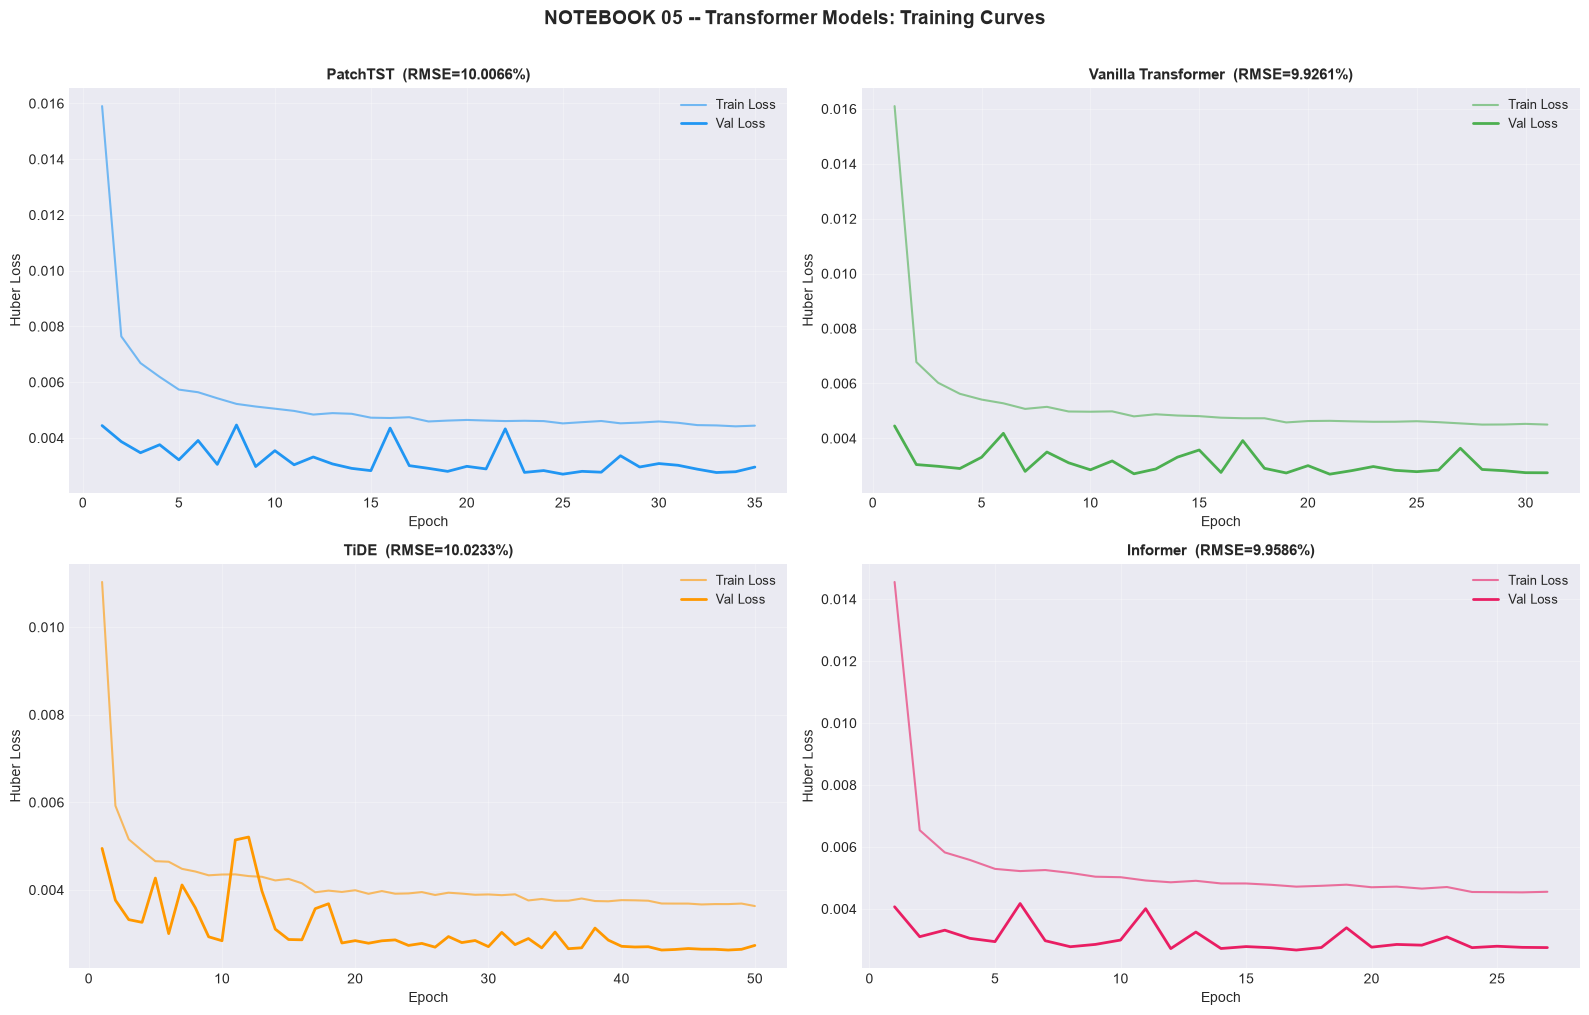

Saved: transformer_training_curves.png


In [15]:
# Plot 1: Training curves (val loss) for all 4 models
fig, axes = plt.subplots(2, 2, figsize=(16, 10), sharex=False)
axes = axes.flatten()

colors = ["#2196F3", "#4CAF50", "#FF9800", "#E91E63"]
models_plot = list(ALL_HIST.items())

for ax, (name, (t_hist, v_hist)), color in zip(axes, models_plot, colors):
    ep = range(1, len(t_hist) + 1)
    ax.plot(ep, t_hist, label="Train Loss", color=color, alpha=0.6, lw=1.5)
    ax.plot(ep, v_hist, label="Val Loss",   color=color, lw=2.0)
    ax.set_title(f"{name}  (RMSE={ALL_RESULTS[name]['RMSE']:.4f}%)", fontsize=11, fontweight="bold")
    ax.set_xlabel("Epoch")
    ax.set_ylabel("Huber Loss")
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)

plt.suptitle("NOTEBOOK 05 -- Transformer Models: Training Curves",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/transformer_training_curves.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: transformer_training_curves.png")

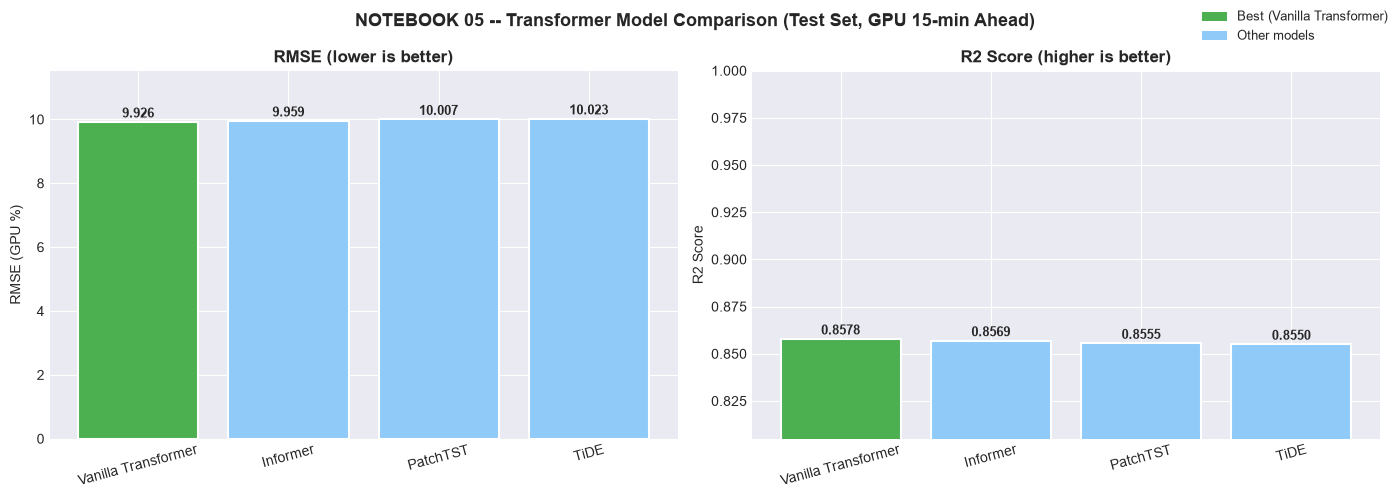

Saved: transformer_model_comparison.png


In [16]:
# Plot 2: Model comparison bar chart
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

model_names = results_df.index.tolist()
rmse_vals   = [ALL_RESULTS[m]["RMSE"] for m in model_names]
r2_vals     = [ALL_RESULTS[m]["R2"]   for m in model_names]
bar_colors  = ["#4CAF50" if m == best_transformer else "#90CAF9" for m in model_names]

# RMSE
bars = axes[0].bar(model_names, rmse_vals, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[0].set_title("RMSE (lower is better)", fontsize=12, fontweight="bold")
axes[0].set_ylabel("RMSE (GPU %)")
axes[0].set_ylim(0, max(rmse_vals) * 1.15)
axes[0].tick_params(axis='x', rotation=15)
for bar, val in zip(bars, rmse_vals):
    axes[0].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.05,
                 f"{val:.3f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

# R2
bars2 = axes[1].bar(model_names, r2_vals, color=bar_colors, edgecolor="white", linewidth=1.5)
axes[1].set_title("R2 Score (higher is better)", fontsize=12, fontweight="bold")
axes[1].set_ylabel("R2 Score")
axes[1].set_ylim(max(0, min(r2_vals) - 0.05), 1.0)
axes[1].tick_params(axis='x', rotation=15)
for bar, val in zip(bars2, r2_vals):
    axes[1].text(bar.get_x() + bar.get_width()/2, bar.get_height() + 0.001,
                 f"{val:.4f}", ha="center", va="bottom", fontsize=9, fontweight="bold")

from matplotlib.patches import Patch
legend_elements = [Patch(facecolor='#4CAF50', label=f'Best ({best_transformer})'),
                   Patch(facecolor='#90CAF9', label='Other models')]
fig.legend(handles=legend_elements, loc="upper right", fontsize=9)

plt.suptitle("NOTEBOOK 05 -- Transformer Model Comparison (Test Set, GPU 15-min Ahead)",
             fontsize=13, fontweight="bold")
plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/transformer_model_comparison.png", dpi=120, bbox_inches="tight")
plt.show()
print("Saved: transformer_model_comparison.png")

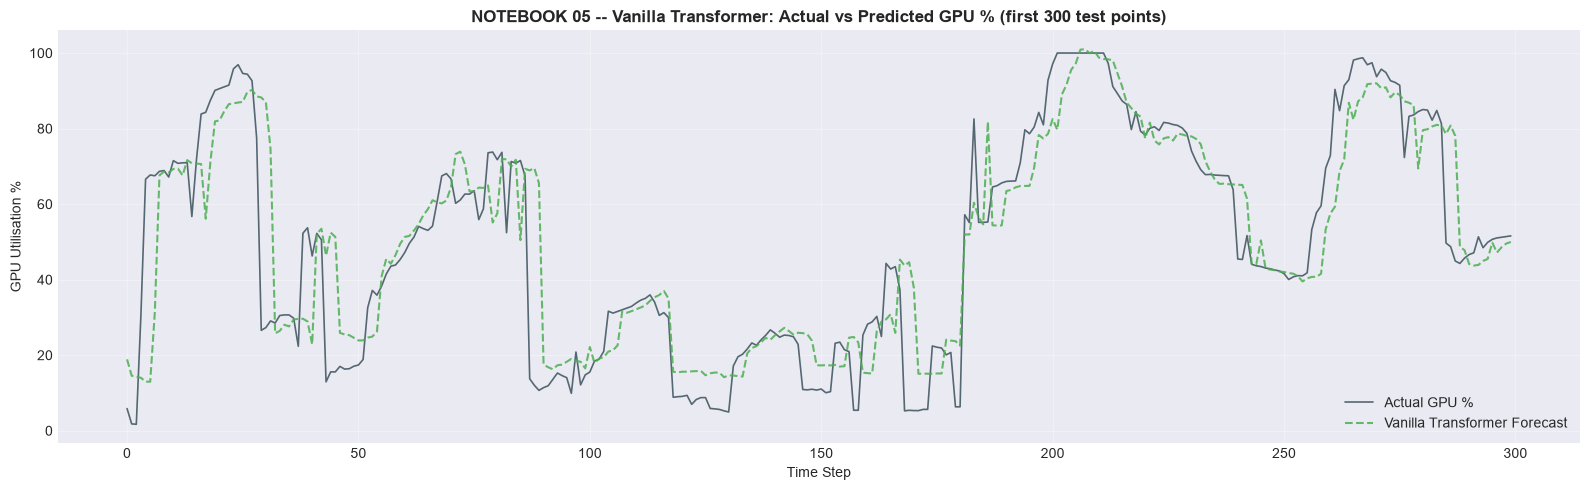

Saved: transformer_best_predictions.png


In [17]:
# Plot 3: Actual vs Predicted (best model, first 300 test points)
best_preds = ALL_PREDS[best_transformer]
best_acts  = patchtst_acts   # all models share same test targets
n_show     = min(300, len(best_acts))

fig, ax = plt.subplots(figsize=(16, 5))
ax.plot(best_acts[:n_show],  label="Actual GPU %",
        color="#455A64", lw=1.2, alpha=0.9)
ax.plot(best_preds[:n_show], label=f"{best_transformer} Forecast",
        color="#4CAF50", lw=1.5, alpha=0.85, linestyle="--")

ax.set_title(f"NOTEBOOK 05 -- {best_transformer}: Actual vs Predicted GPU % (first {n_show} test points)",
             fontsize=12, fontweight="bold")
ax.set_xlabel("Time Step")
ax.set_ylabel("GPU Utilisation %")
ax.legend(fontsize=10)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(f"{REPORT_DIR}/transformer_best_predictions.png", dpi=120, bbox_inches="tight")
plt.show()
print(f"Saved: transformer_best_predictions.png")

In [18]:
# Cross-notebook summary: compare with ML (NB03) and DL (NB04) best models
summary_rows = []

ml_csv = f"{REPORT_DIR}/ml_model_comparison.csv"
dl_csv = f"{REPORT_DIR}/dl_model_comparison.csv"

if os.path.exists(ml_csv):
    ml_df = pd.read_csv(ml_csv, index_col=0)
    best_ml_name = ml_df.sort_values("RMSE").index[0]
    best_ml_row  = ml_df.loc[best_ml_name]
    summary_rows.append({"Group": "ML (NB03)",
                          "Model": best_ml_name,
                          "MAE":  round(float(best_ml_row["MAE"]),  4),
                          "RMSE": round(float(best_ml_row["RMSE"]), 4),
                          "R2":   round(float(best_ml_row["R2"]) if "R2" in best_ml_row else float(best_ml_row.get("R²", 0)), 4),
                          "MAPE": round(float(best_ml_row["MAPE"]), 4)})

if os.path.exists(dl_csv):
    dl_df = pd.read_csv(dl_csv, index_col=0)
    best_dl_name = dl_df.sort_values("RMSE").index[0]
    best_dl_row  = dl_df.loc[best_dl_name]
    summary_rows.append({"Group": "DL (NB04)",
                          "Model": best_dl_name,
                          "MAE":  round(float(best_dl_row["MAE"]),  4),
                          "RMSE": round(float(best_dl_row["RMSE"]), 4),
                          "R2":   round(float(best_dl_row["R2"]) if "R2" in best_dl_row else float(best_dl_row.get("R²", 0)), 4),
                          "MAPE": round(float(best_dl_row["MAPE"]), 4)})

for name in results_df.index:
    m = ALL_RESULTS[name]
    summary_rows.append({"Group": "Transformer (NB05)",
                          "Model": name,
                          "MAE":  round(m["MAE"],  4),
                          "RMSE": round(m["RMSE"], 4),
                          "R2":   round(m["R2"],   4),
                          "MAPE": round(m["MAPE"], 4)})

if summary_rows:
    summary_df = pd.DataFrame(summary_rows).sort_values("RMSE").reset_index(drop=True)
    summary_df.index = summary_df.index + 1
    summary_df["Rank"] = summary_df.index

    print("=" * 70)
    print("  CROSS-NOTEBOOK SUMMARY -- Best ML vs Best DL vs All Transformers")
    print("=" * 70)
    print(f"  {'Rank':<5} {'Group':<22} {'Model':<24} {'RMSE':>8} {'R2':>8}")
    print(f"  {'_'*5} {'_'*22} {'_'*24} {'_'*8} {'_'*8}")
    for _, row in summary_df.iterrows():
        print(f"  {int(row['Rank']):<5} {row['Group']:<22} {row['Model']:<24} {row['RMSE']:>8.4f} {row['R2']:>8.4f}")

    overall_best = summary_df.iloc[0]
    print(f"\n  Overall Best : {overall_best['Model']} ({overall_best['Group']})")
    print(f"     RMSE : {overall_best['RMSE']:.4f}%")
    print(f"     R2   : {overall_best['R2']:.4f}")

    summary_df.to_csv(f"{REPORT_DIR}/all_models_summary.csv", index=False)
    print(f"\n  Saved: all_models_summary.csv")
else:
    print("No prior comparison CSVs found. Run NB03 and NB04 first for full cross-notebook summary.")

  CROSS-NOTEBOOK SUMMARY -- Best ML vs Best DL vs All Transformers
  Rank  Group                  Model                        RMSE       R2
  _____ ______________________ ________________________ ________ ________
  1     ML (NB03)              RandomForest               9.4304   0.8729
  2     Transformer (NB05)     Vanilla Transformer        9.9261   0.8578
  3     Transformer (NB05)     Informer                   9.9586   0.8569
  4     DL (NB04)              CNN+LSTM                   9.9746   0.8564
  5     Transformer (NB05)     PatchTST                  10.0066   0.8555
  6     Transformer (NB05)     TiDE                      10.0233   0.8550

  Overall Best : RandomForest (ML (NB03))
     RMSE : 9.4304%
     R2   : 0.8729

  Saved: all_models_summary.csv
